# Fine tune membrane cut for nice display

In [21]:
import os
import skimage
import matplotlib.pyplot as plt
import numpy as np

In [39]:
def extract_center_face(im, IFcoords):

    shp = IFcoords.shape
    interface = np.zeros(shp)
    for x in range(shp[0]):
        for y in range(shp[1]):
            z = IFcoords[x,y]
            interface[x,y] = im[x,y,z-4:z+4].min()
            # interface[x,y] = im[x-fs:x+fs,y-fs:y+fs,z-fs:z+fs].mean()  #small mean filtering

    return interface

In [30]:
vmin = -0.0587
vmax = 0.3144

In [51]:
sample = 'D_2'

In [52]:
toppath = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/'

In [53]:
im0 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_preop_rotcrop.tif'))[100:1100,50:550,:]
im1 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_1_rotcrop.tif'))[100:1100,50:550,:]
im2 = skimage.io.imread(os.path.join(toppath, sample[0]+'_series', sample, sample+'_postop_2_rotcrop.tif'))[100:1100,50:550,:]

In [67]:
memcut0 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_preop__membrane_cut.tif'))
memcut1 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_postop_1__membrane_cut.tif'))
memcut2 = skimage.io.imread(os.path.join(toppath, 'membrane_cut', sample+'_postop_2__membrane_cut.tif'))

mempos0 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_preop__membrane_cut_position.tif'))
mempos1 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_postop_1__membrane_cut_position.tif'))
mempos2 = skimage.io.imread(os.path.join(toppath, 'membrane_cut_positions', sample+'_postop_2__membrane_cut_position.tif'))

In [65]:
sl = 420

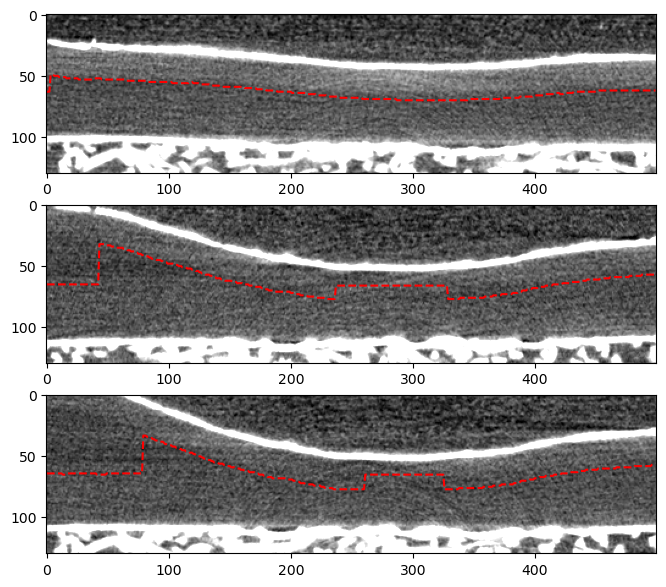

In [69]:
fig, axs = plt.subplots(3,1,figsize=(10,7))
axs[0].imshow(np.transpose(im0[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(np.transpose(im1[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(np.transpose(im2[sl,:,:], (1,0)), 'gray', vmin=vmin, vmax=vmax)

shift = 3
axs[0].plot(mempos0[sl,:]-shift, 'r--')
axs[1].plot(mempos1[sl,:]-shift, 'r--')
axs[2].plot(mempos2[sl,:]-shift, 'r--')

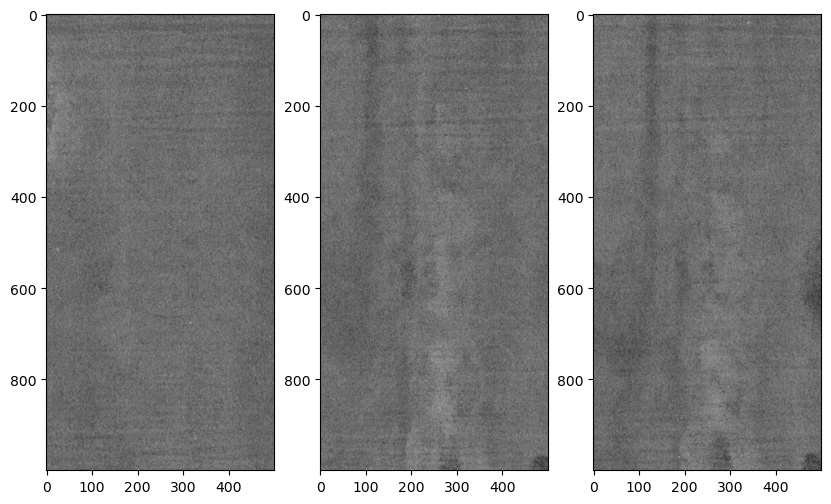

In [68]:
fig, axs = plt.subplots(1,3, figsize=(10,7))

axs[0].imshow(memcut0, 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(memcut1, 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(memcut2, 'gray', vmin=vmin, vmax=vmax)

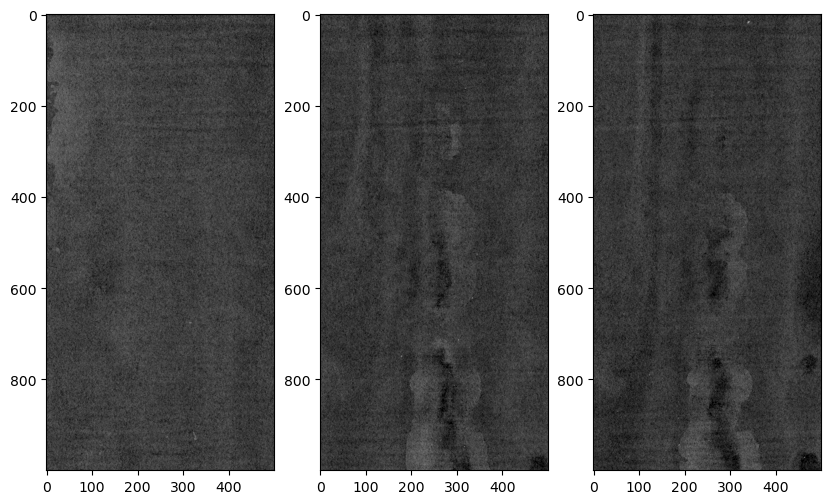

In [64]:
fig, axs = plt.subplots(1,3, figsize=(10,7))

axs[0].imshow(extract_center_face(im0, mempos0-5), 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(extract_center_face(im1, mempos1-5), 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(extract_center_face(im2, mempos2-5), 'gray', vmin=vmin, vmax=vmax)